In [4]:
import numpy as np

# Wczytanie danych
cechy = np.load("C:\\Users\\HP\\Desktop\\project\\Klasyfikacja-raka-prostaty-na-podstawie-vokseli\\data\\x_data_corrected_pz.npy")
wzorce = np.load("C:\\Users\\HP\\Desktop\\project\\Klasyfikacja-raka-prostaty-na-podstawie-vokseli\\data\\y_labels_pz.npy")
pacjenci = np.load("C:\\Users\\HP\\Desktop\\project\\Klasyfikacja-raka-prostaty-na-podstawie-vokseli\\data\\patient_labels_pz.npy")

print("KSZTAŁTY DANYCH")
print("Cechy: ", cechy.shape)
print("Wzorce: ", wzorce.shape)
print("Pacjenci: ", pacjenci.shape)

print()

print("WYGLĄD DANYCH")
print("Cechy: \n", cechy)
print("Wzorce: \n", wzorce)
print("Pacjenci: \n", pacjenci)

KSZTAŁTY DANYCH
Cechy:  (248346, 48)
Wzorce:  (248346,)
Pacjenci:  (248346,)

WYGLĄD DANYCH
Cechy: 
 [[ 450.         1299.          305.70968628 ...  477.91494751
   466.22271729  484.36581421]
 [ 487.         1312.          311.28347778 ...  456.14321899
   460.65151978  475.01937866]
 [ 514.         1292.          297.86135864 ...  444.92749023
   468.01870728  467.68884277]
 ...
 [ 264.          663.          113.85424042 ...  430.85629272
   369.75836182  368.01037598]
 [ 282.          603.          100.81270599 ...  395.81542969
   324.79873657  317.197052  ]
 [ 327.          535.           86.12051392 ...  333.05081177
   279.92041016  271.30245972]]
Wzorce: 
 [0 0 0 ... 1 1 1]
Pacjenci: 
 [0 0 0 ... 8 8 8]


In [5]:
# Liczba danych
liczba_nowotworow = sum(wzorce)
liczba_zdrowych = len(wzorce) - liczba_nowotworow
stosunek_nowotworow = liczba_nowotworow/len(wzorce)

print("Liczba wokseli z nowotworem: ", liczba_nowotworow)
print("Liczba wokseli z bez nowotworu: ", liczba_zdrowych)
print("Stosunek wokseli z nowotworem: ", round(stosunek_nowotworow, 4))

Liczba wokseli z nowotworem:  84150
Liczba wokseli z bez nowotworu:  164196
Stosunek wokseli z nowotworem:  0.3388


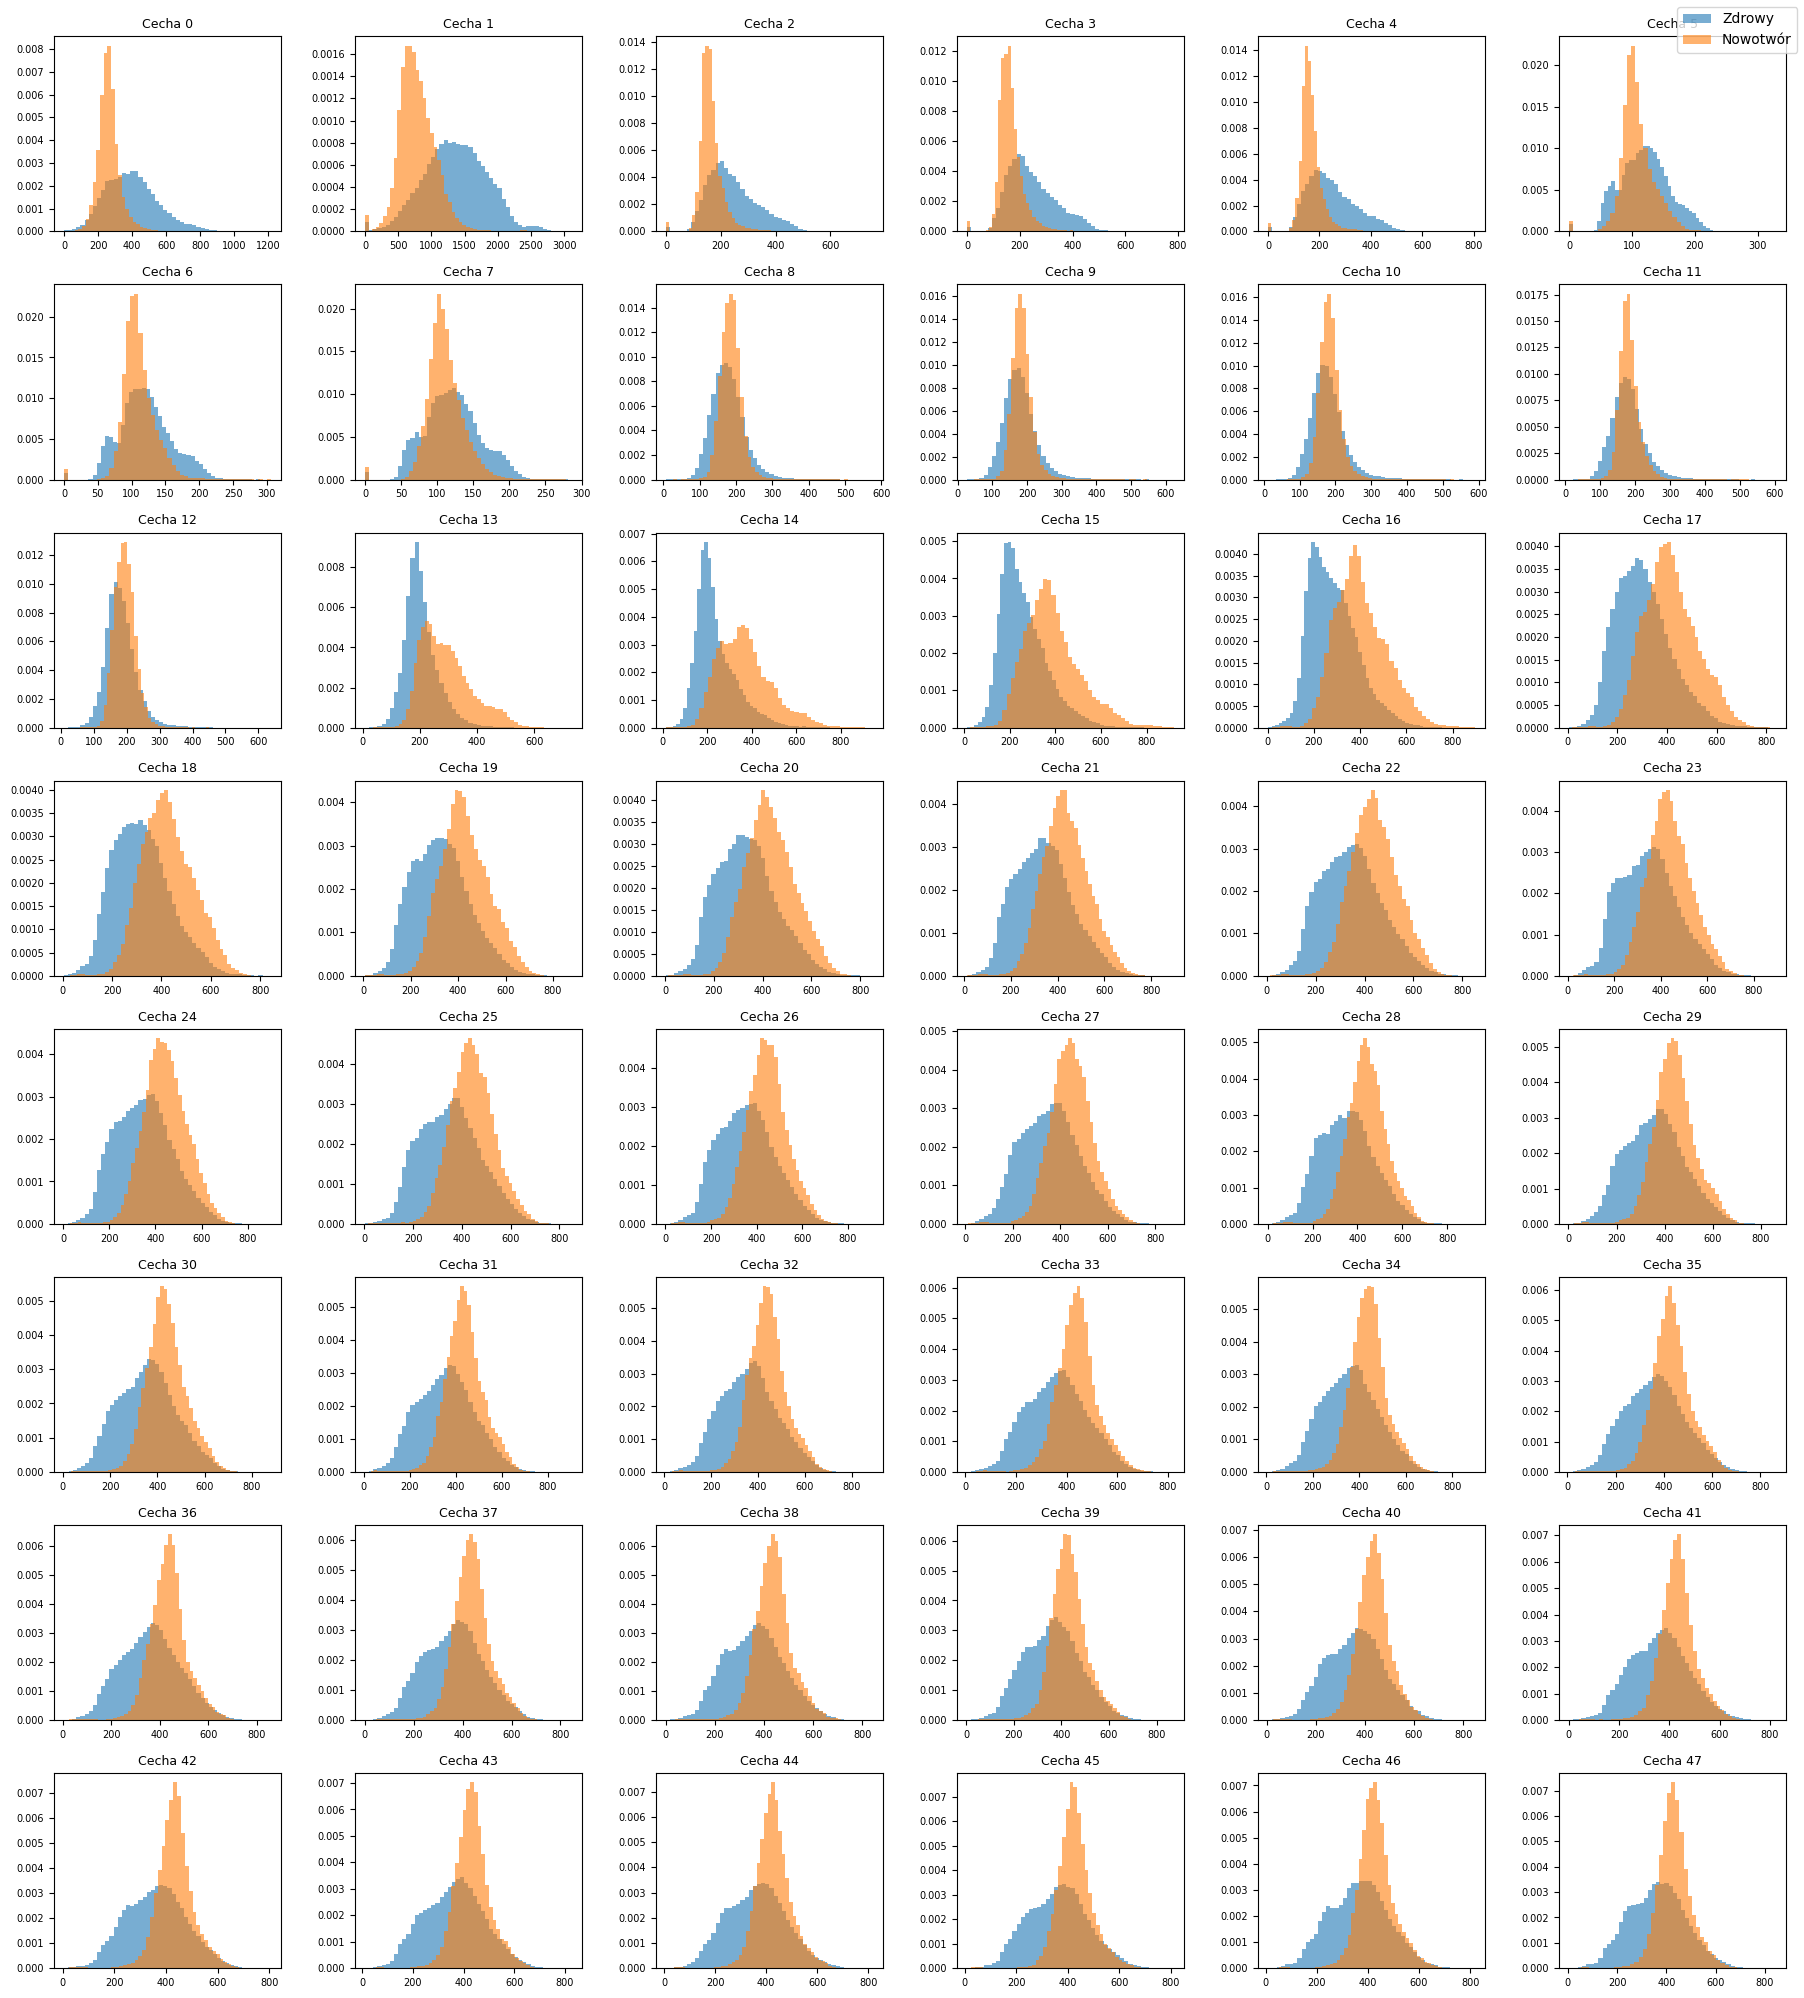

In [6]:
import matplotlib.pyplot as plt
import math

n_features = 48
n_cols = 6
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3 * n_cols, 2.5 * n_rows))

axes = axes.flatten()

for i in range(n_features):
    ax = axes[i]

    healthy = cechy[wzorce == 0, i]
    cancer  = cechy[wzorce == 1, i]

    ax.hist(healthy, bins=50, alpha=0.6, density=True, label="Zdrowy")
    ax.hist(cancer,  bins=50, alpha=0.6, density=True, label="Nowotwór")

    ax.set_title(f"Cecha {i}", fontsize=9)
    ax.tick_params(axis='both', labelsize=7)

for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

In [7]:
BALANCE_STRATEGY = "undersample"
rng = np.random.default_rng(48)

unique_patients = np.unique(pacjenci)

balanced_X = []
balanced_y = []
balanced_p = []

print("=== BALANS PER PACJENT ===")

for patient in unique_patients:
    idx = np.where(pacjenci == patient)[0]

    X_p = cechy[idx]
    y_p = wzorce[idx]

    pos_idx = np.where(y_p == 1)[0]
    neg_idx = np.where(y_p == 0)[0]

    n_pos = len(pos_idx)
    n_neg = len(neg_idx)

    print(f"Pacjent {patient}: przed balansowaniem -> 0={n_neg}, 1={n_pos}")

    # --- balansowanie ---
    if BALANCE_STRATEGY == "undersample":
        n = min(n_pos, n_neg)
        sel_pos = rng.choice(pos_idx, size=n, replace=False)
        sel_neg = rng.choice(neg_idx, size=n, replace=False)

    else:
        raise ValueError("BALANCE_STRATEGY musi być 'undersample' lub 'oversample'")

    selected = np.concatenate([sel_pos, sel_neg])
    rng.shuffle(selected)

    balanced_X.append(X_p[selected])
    balanced_y.append(y_p[selected])
    balanced_p.append(np.full(len(selected), patient))

    print(f"Pacjent {patient}: po balansowaniu -> 0={n}, 1={n}")

# --- sklejenie ---
X_bal = np.vstack(balanced_X)
y_bal = np.concatenate(balanced_y)
p_bal = np.concatenate(balanced_p)

print("\n=== PODSUMOWANIE CAŁOŚCI ===")
print("X_bal:", X_bal.shape)
print("y_bal:", y_bal.shape)
print("p_bal:", p_bal.shape)
print("Unikalnych pacjentów po balansowaniu:", len(np.unique(p_bal)))

cechy = X_bal
wzorce = y_bal
pacjenci = p_bal

=== BALANS PER PACJENT ===
Pacjent 0: przed balansowaniem -> 0=3174, 1=2803
Pacjent 0: po balansowaniu -> 0=2803, 1=2803
Pacjent 1: przed balansowaniem -> 0=15207, 1=0
Pacjent 1: po balansowaniu -> 0=0, 1=0
Pacjent 2: przed balansowaniem -> 0=32207, 1=13857
Pacjent 2: po balansowaniu -> 0=13857, 1=13857
Pacjent 3: przed balansowaniem -> 0=13160, 1=15630
Pacjent 3: po balansowaniu -> 0=13160, 1=13160
Pacjent 4: przed balansowaniem -> 0=21571, 1=4688
Pacjent 4: po balansowaniu -> 0=4688, 1=4688
Pacjent 5: przed balansowaniem -> 0=20546, 1=1430
Pacjent 5: po balansowaniu -> 0=1430, 1=1430
Pacjent 6: przed balansowaniem -> 0=19751, 1=0
Pacjent 6: po balansowaniu -> 0=0, 1=0
Pacjent 7: przed balansowaniem -> 0=19827, 1=2477
Pacjent 7: po balansowaniu -> 0=2477, 1=2477
Pacjent 8: przed balansowaniem -> 0=18753, 1=43265
Pacjent 8: po balansowaniu -> 0=18753, 1=18753

=== PODSUMOWANIE CAŁOŚCI ===
X_bal: (114336, 48)
y_bal: (114336,)
p_bal: (114336,)
Unikalnych pacjentów po balansowaniu: 7


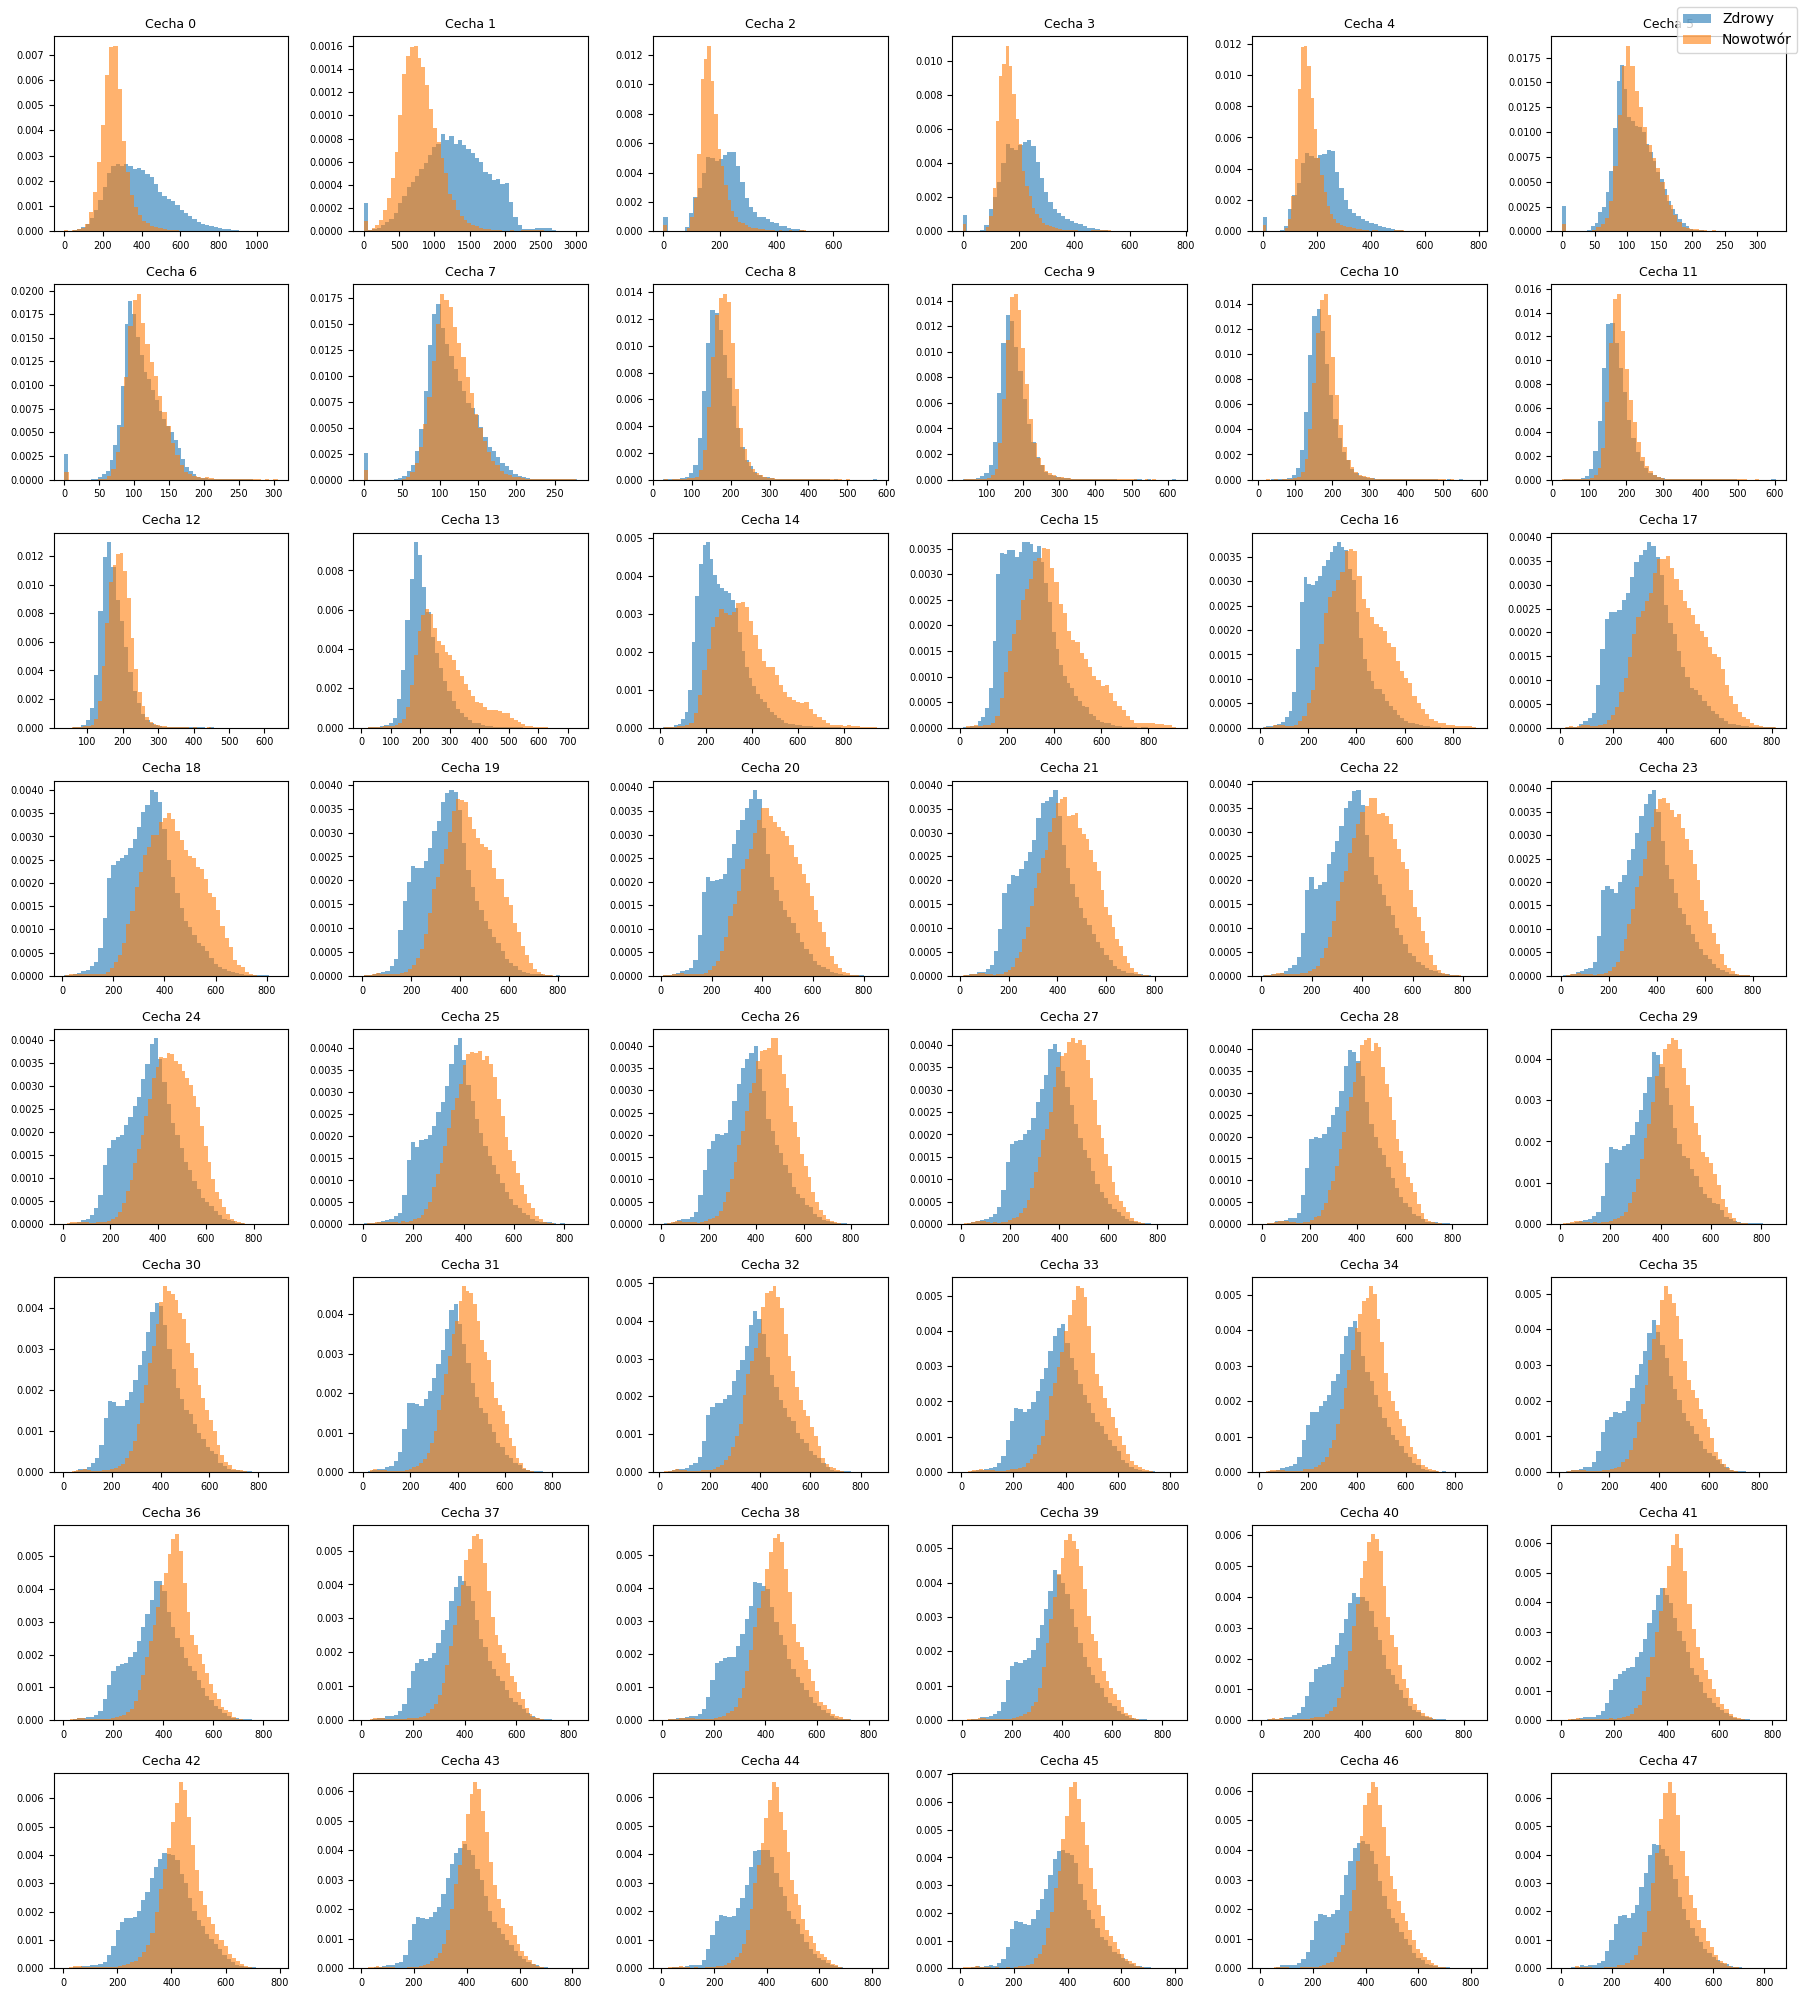

In [8]:
n_features = 48
n_cols = 6
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3 * n_cols, 2.5 * n_rows))

axes = axes.flatten()

for i in range(n_features):
    ax = axes[i]

    healthy = cechy[wzorce == 0, i]
    cancer  = cechy[wzorce == 1, i]

    ax.hist(healthy, bins=50, alpha=0.6, density=True, label="Zdrowy")
    ax.hist(cancer,  bins=50, alpha=0.6, density=True, label="Nowotwór")

    ax.set_title(f"Cecha {i}", fontsize=9)
    ax.tick_params(axis='both', labelsize=7)

for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import GroupShuffleSplit

# Najpierw wydzielamy test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss.split(cechy, wzorce, groups=pacjenci))

X_train_val, X_test = cechy[train_val_idx], cechy[test_idx]
y_train_val, y_test = wzorce[train_val_idx], wzorce[test_idx]
patients_train_val = pacjenci[train_val_idx]
# Teraz walidacja z train
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss_val.split(X_train_val, y_train_val, groups=patients_train_val))

X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]

In [10]:
import numpy as np

def info(name, X, y, p):
    print(f"{name}: pacjenci={len(np.unique(p))}, próbki={len(y)}, klasa1={int((y==1).sum())}, klasa0={int((y==0).sum())}")

info("TRAIN", X_train, y_train, patients_train_val[train_idx])
info("VAL  ", X_val,   y_val,   patients_train_val[val_idx])
info("TEST ", X_test,  y_test,  pacjenci[test_idx])

print("\nPacjenci (train):", np.unique(patients_train_val[train_idx]))
print("Pacjenci (val)  :", np.unique(patients_train_val[val_idx]))
print("Pacjenci (test) :", np.unique(pacjenci[test_idx]))

TRAIN: pacjenci=4, próbki=71640, klasa1=35820, klasa0=35820
VAL  : pacjenci=1, próbki=9376, klasa1=4688, klasa0=4688
TEST : pacjenci=2, próbki=33320, klasa1=16660, klasa0=16660

Pacjenci (train): [3 5 7 8]
Pacjenci (val)  : [4]
Pacjenci (test) : [0 2]


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_b = scaler.fit_transform(X_train)
X_val_b   = scaler.transform(X_val)
X_test_b  = scaler.transform(X_test)

In [12]:
from sklearn.decomposition import PCA

# liczba składowych – sensowny zakres: 10–20
pca = PCA(n_components=10, random_state=42)

X_train_pca = pca.fit_transform(X_train_b)
X_val_pca   = pca.transform(X_val_b)
X_test_pca  = pca.transform(X_test_b)

print("Wyjaśniona wariancja (suma):",
      pca.explained_variance_ratio_.sum())


Wyjaśniona wariancja (suma): 0.9577991636232964


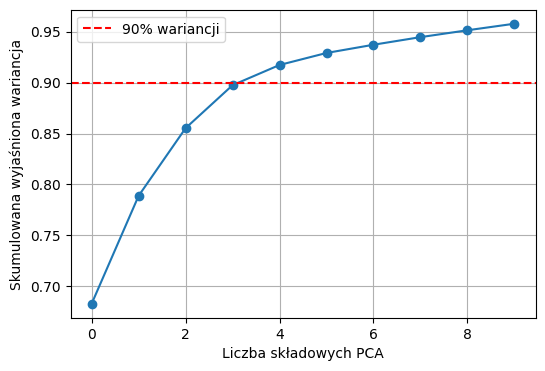

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.90, color='r', linestyle='--', label='90% wariancji')
plt.xlabel("Liczba składowych PCA")
plt.ylabel("Skumulowana wyjaśniona wariancja")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras import callbacks, optimizers, losses
import tensorflow as tf

model = Sequential([
    Dense(128, input_shape=(10,),
          kernel_regularizer=l2(1e-2)),
    LeakyReLU(alpha=0.05),
    Dropout(0.5),

    Dense(64, kernel_regularizer=l2(1e-2)),
    LeakyReLU(alpha=0.05),
    Dropout(0.2),

    Dense(32, kernel_regularizer=l2(1e-2)),
    LeakyReLU(alpha=0.05),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss=losses.BinaryFocalCrossentropy(alpha=0.25, gamma=2.0),
    metrics=[
        tf.keras.metrics.Recall(name='Recall'), 
        tf.keras.metrics.AUC(name='AUC'),
        tf.keras.metrics.Precision(name="Precision")
    ]
)

model.summary()

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

history = model.fit(
    X_train_pca,
    y_train,
    validation_data=(X_val_pca, y_val),
    epochs=100,
    batch_size=1024,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    shuffle=True
)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - AUC: 0.8158 - Precision: 0.7362 - Recall: 0.7330 - loss: 1.1027 - val_AUC: 0.9019 - val_Precision: 0.8936 - val_Recall: 0.6308 - val_loss: 0.6663 - learning_rate: 0.0010
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - AUC: 0.8844 - Precision: 0.7854 - Recall: 0.8143 - loss: 0.4534 - val_AUC: 0.9005 - val_Precision: 0.8846 - val_Recall: 0.6724 - val_loss: 0.3011 - learning_rate: 0.0010
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - AUC: 0.8968 - Precision: 0.7974 - Recall: 0.8224 - loss: 0.2248 - val_AUC: 0.9058 - val_Precision: 0.8813 - val_Recall: 0.7203 - val_loss: 0.1754 - learning_rate: 0.0010
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - AUC: 0.9011 - Precision: 0.7989 - Recall: 0.8291 - loss: 0.1516 - val_AUC: 0.9059 - val_Precision: 0.8765 - val_Recall: 0.7218 - val_loss: 0.1379 - learning_rate: 0.0010
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - AUC: 0.9033 - Precision: 0.8015 - Recall: 0.8314 -

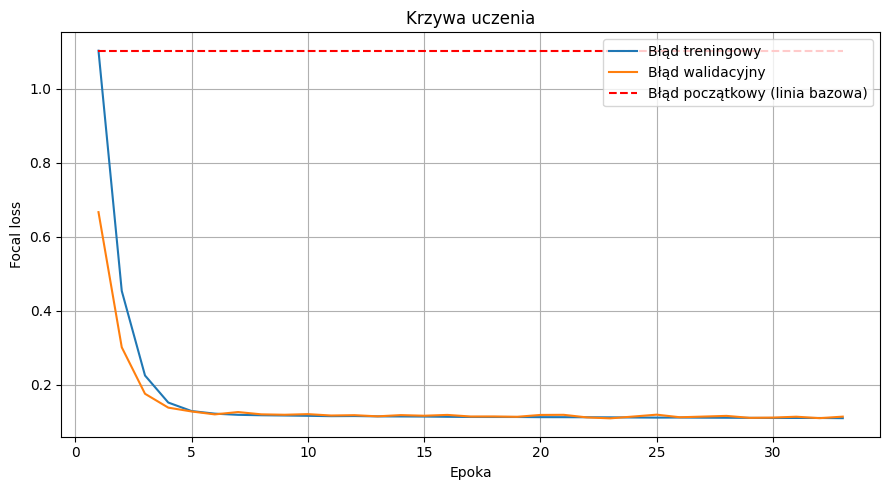

In [15]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs, history.history['loss'], label='Błąd treningowy')
plt.plot(epochs, history.history['val_loss'], label='Błąd walidacyjny')
baseline_loss = history.history['loss'][0]
plt.hlines(
    baseline_loss,
    xmin=1,
    xmax=len(epochs),
    colors='r',
    linestyles='dashed',
    label='Błąd początkowy (linia bazowa)'
)
plt.xlabel('Epoka')
plt.ylabel('Focal loss')
plt.title('Krzywa uczenia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Precision: 0.6673
Recall:    0.8620
F2-score:  0.8145


<Figure size 500x500 with 0 Axes>

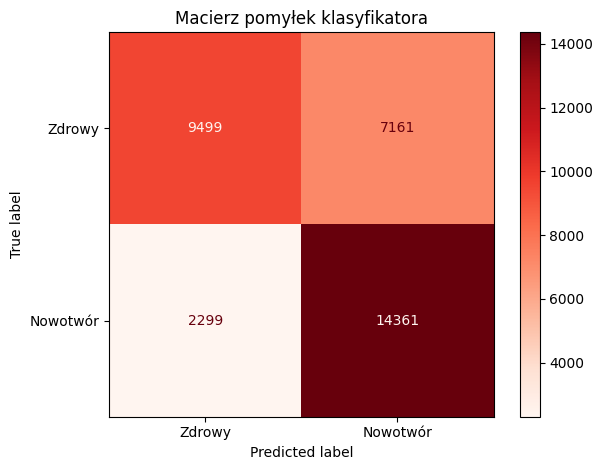

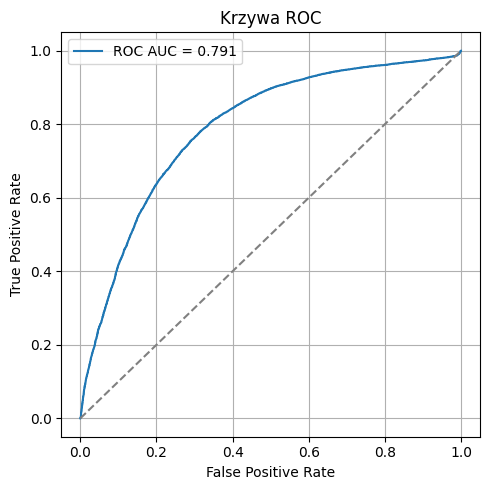

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    fbeta_score
)


y_test_pred_prob = model.predict(X_test_pca, verbose=0).ravel()
roc_auc = roc_auc_score(y_test, y_test_pred_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_prob)

threshold = 0.5
# Predykcja binarna
y_test_pred = (y_test_pred_prob >= threshold).astype(int)

# Metryki końcowe
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall    = recall_score(y_test, y_test_pred, zero_division=0)
f2        = fbeta_score(y_test, y_test_pred, beta=2, zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F2-score:  {f2:.4f}")

plt.figure(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=['Zdrowy', 'Nowotwór'],
    cmap='Reds',
    colorbar=True
)
plt.title("Macierz pomyłek klasyfikatora")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywa ROC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()